## 02. Exploratory Data Analysis (EDA)
##### Focus
- Long-term trend (2000–present)
- Growth dynamics (YoY, CAGR)
- Periods of growth / stagnation / decline
- Contextual linkage to energy market events
  - Oil/Gas Price Cycle
  - Shale Revolution
  - COVID
  - LNG Canada FID Before and After

##### Handling of Missing Values

Missing values are retained during the EDA stage. In this dataset, missing observations primarily reflect data availability and reporting structure rather than true zero production.

Aggregations (annual averages, growth rates) rely on pandas’ default NaN handling, which excludes missing values without introducing artificial trends. Imputation is deferred to later modeling stages if required.

In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

BASE_PATH = "/Workspace/Users/kimjylin@gmail.com/ca_gas_supply_trends"
df = pd.read_csv(
    f"{BASE_PATH}/data/processed/canadian_marketable_gas_2000_25_103m3d.csv"
)

df.head()

,Year,Month,Province,Production_e3m3d
0,2000,January,Alberta,387095.0
1,2000,January,British Columbia,54389.0
2,2000,January,Canada Total,463099.0
3,2000,January,NWT & Yukon,1783.0
4,2000,January,New Brunswick,0.0


In [0]:
df_can = df[df["Province"] == "Canada Total"].copy()
annual_df = (
    df_can
    .groupby("Year", as_index=False)
    ["Production_e3m3d"]
    .mean()
)

### Long-term trend (2000 → present)

To begin, we examine the long-term trend in Canada’s average annual marketable natural gas production from 2000 to the most recent year.

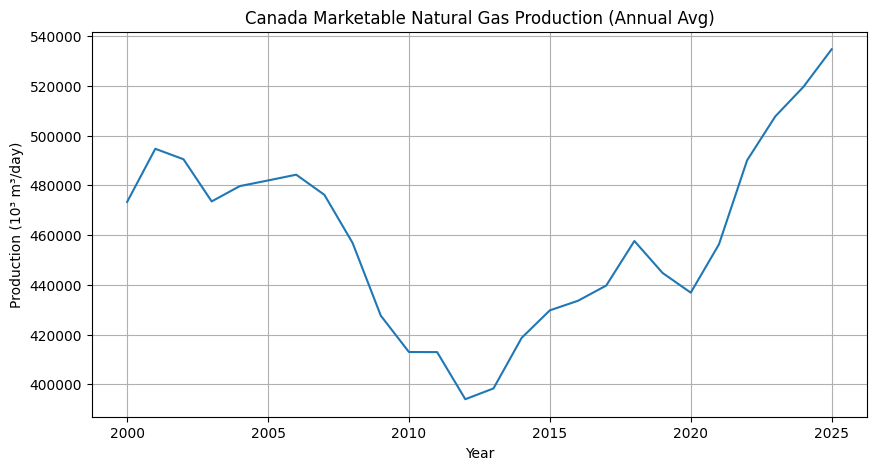

In [0]:
plt.figure(figsize=(10,5))
plt.plot(
    annual_df["Year"],
    annual_df["Production_e3m3d"]
)
plt.title("Canada Marketable Natural Gas Production (Annual Avg)")
plt.xlabel("Year")
plt.ylabel("Production (10³ m³/day)")
plt.grid(True)
plt.show()

##### Retain "Monthly Fluctuations" and "Yearly Trends"
We also plot monthly fluctuations alongside the annual trends to better examine the overall volatility in production.

In [0]:
MONTH_MAP = {
    "January": 1, "February": 2, "March": 3, "April": 4,
    "May": 5, "June": 6, "July": 7, "August": 8,
    "September": 9, "October": 10, "November": 11, "December": 12
}

df_can["Month_num"] = df_can["Month"].map(MONTH_MAP)

df_can[["Month", "Month_num"]].drop_duplicates().sort_values("Month_num")


,Month,Month_num
2,January,1
10,February,2
18,March,3
26,April,4
34,May,5
42,June,6
50,July,7
58,August,8
66,September,9
74,October,10


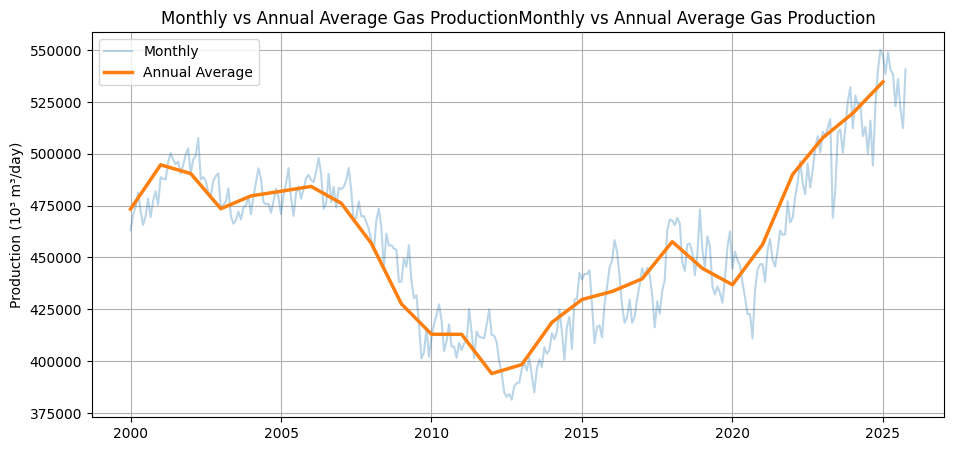

In [0]:
plt.figure(figsize=(11,5))

plt.plot(
    df_can["Year"] + (df_can["Month_num"]-1)/12,
    df_can["Production_e3m3d"],
    alpha=0.3,
    label="Monthly"
)

plt.plot(
    annual_df["Year"],
    annual_df["Production_e3m3d"],
    linewidth=2.5,
    label="Annual Average"
)

plt.legend()
plt.title("Monthly vs Annual Average Gas ProductionMonthly vs Annual Average Gas Production")
plt.ylabel("Production (10³ m³/day)")
plt.grid(True)
plt.show()

### Growth dynamics
##### YoY growth
Year-over-Year (YoY) growth measures the percentage change of a variable compared with the same period in the previous year, helping to identify annual growth or contraction while removing seasonal effects.

In [0]:
annual_df["YoY_pct"] = annual_df["Production_e3m3d"].pct_change() * 100

In [0]:
annual_df.head(10)

,Year,Production_e3m3d,YoY_pct
0,2000,473329.500000,NaN
1,2001,494688.250000,4.512449
2,2002,490478.666667,-0.850957
3,2003,473534.583333,-3.454601
4,2004,479693.416667,1.300609
5,2005,481949.750000,0.470370
6,2006,484277.416667,0.482969
7,2007,476172.916667,-1.673524
8,2008,456841.750000,-4.059695
9,2009,427625.333333,-6.395304


Each year is classified into a regime based on the magnitude of growth:
- Growth (green): YoY increase > 3%
- Stagnation (gray): YoY change between -3% and 3%
- Decline (red): YoY decrease < -3%

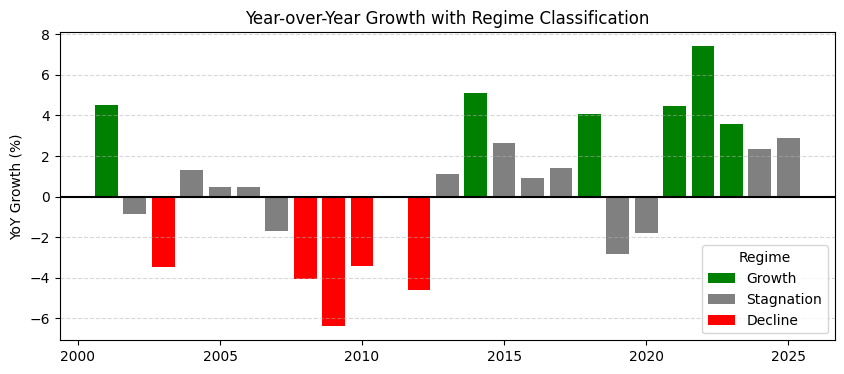

In [0]:
def classify_growth(x):
    if x > 3:       # >3% = growth
        return "Growth"
    elif x < -3:    # <-3% = decline
        return "Decline"
    else:           # -3%~3% = stagnation
        return "Stagnation"

annual_df["Regime"] = annual_df["YoY_pct"].apply(classify_growth)
annual_df[["Year", "YoY_pct", "Regime"]].tail(15)

colors = annual_df["Regime"].map({
    "Growth": "green",
    "Stagnation": "gray",
    "Decline": "red"
})

plt.figure(figsize=(10,4))
plt.bar(annual_df["Year"], annual_df["YoY_pct"], color=colors)
plt.axhline(0, color="black")
plt.title("Year-over-Year Growth with Regime Classification")
plt.ylabel("YoY Growth (%)")

legend_elements = [
    Patch(facecolor="green", label="Growth"),
    Patch(facecolor="gray", label="Stagnation"),
    Patch(facecolor="red", label="Decline")
]

plt.legend(handles=legend_elements, title="Regime")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()


From the mid-2000s, Canadian marketable natural gas production experienced a decline, starting around 2006–2007 and continuing through roughly 2012. During this period, the YoY growth plot shows multiple years of negative growth, reflecting both the oil and gas price cycles and the lingering effects of the 2008 financial crisis. Production began to recover after 2012 as the North American shale gas revolution matured, increasing supply. 

Around 2020, production was relatively flat, likely impacted by COVID-19 disruptions and temporary market uncertainty. Since then, production has resumed a growth trend, coinciding with the 2018 final investment decision (FID) for LNG Canada and post-pandemic demand recovery. 

Overall, the combination of long-term trend and YoY analysis highlights how structural shifts, market cycles, and major events shaped Canadian gas production over the past two decades.

##### CAGR
Compound Annual Growth Rate represents the average annual growth rate of a variable over a period of time, assuming growth happens smoothly and compounded year over year.
- CAGR gives a single number summarizing the overall trend.
- Very useful to communicate the long-term trend without being distracted by short-term ups and downs.

In [0]:
df_can = df[df["Province"] == "Canada Total"]

annual = (
    df_can
    .groupby("Year")["Production_e3m3d"]
    .mean()
)

start_year = 2000
end_year = annual.dropna().index.max()

start_value = annual.loc[start_year]
end_value = annual.loc[end_year]

n_years = end_year - start_year

cagr = (end_value / start_value) ** (1 / n_years) - 1

print(f"CAGR ({start_year}–{end_year}): {cagr:.2%}")


CAGR (2000–2025): 0.49%


In [0]:
yoy = annual.pct_change() * 100

conditions = pd.cut(
    yoy,
    bins=[-float("inf"), -1, 1, float("inf")],
    labels=["Decline", "Stagnation", "Growth"]
)

trend_class = pd.DataFrame({
    "YoY_%": yoy,
    "Trend": conditions
})


In [0]:
trend_class["Trend"].value_counts()

Trend
Growth        12
Decline        8
Stagnation     5
Name: count, dtype: int64

From 2000 to 2025, Canadian marketable natural gas production grew slowly but steadily, at an average rate of 0.49% per year. While this may sound small on a yearly basis, the cumulative growth over 25 years is significant. Although there were ups and downs in individual years, the long-term trend shows a slow and consistent increase. 

When we examine each year individually, 12 years experienced strong growth, 8 years saw declines, and 5 years remained relatively flat. This pattern highlights both the long-term upward trend and the natural fluctuations caused by market cycles and global events 